In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

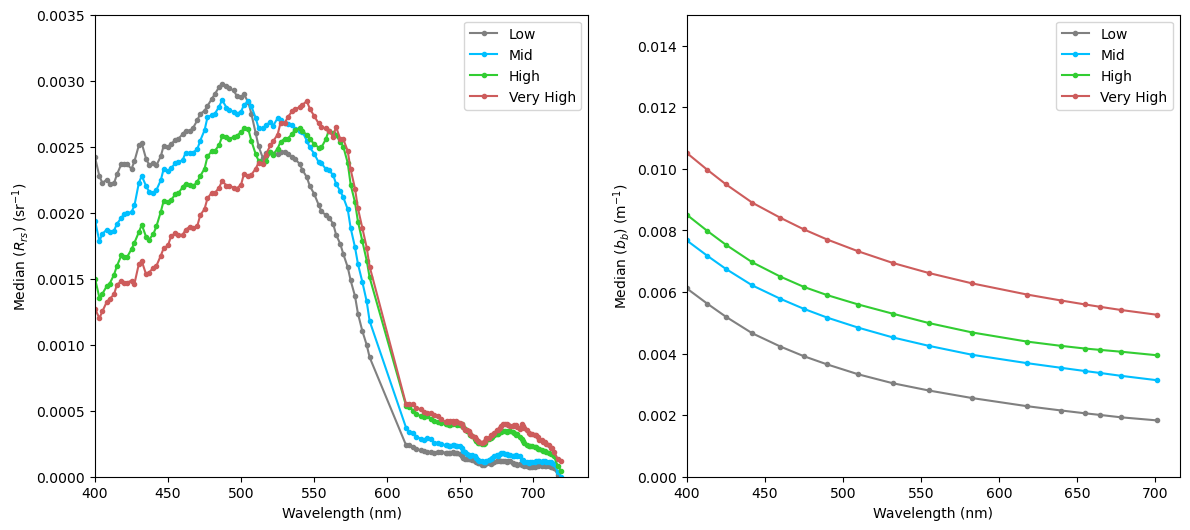

In [6]:
final_df = pd.read_csv("Project Data/final_df.csv")
bb_df = pd.read_csv("Project Data/chl_pick_bb_spectra.csv")
rrs_pn = final_df[final_df["group"] == "No PS but High CH"]
bb_pn = bb_df[bb_df["group"] == "No PS but High CH"]

level_colors = {
    "low": "gray",
    "mid": "deepskyblue",
    "high": "limegreen",
    "very_high": "indianred",}

level_labels = {
    "low": "Low",
    "mid": "Mid",
    "high": "High",
    "very_high": "Very High",}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
#fig.suptitle("No Pseudo-nitzschia Days")

for level in ["low", "mid", "high", "very_high"]:
    color = level_colors[level]
    label = level_labels[level]

    rrs_med = rrs_pn[rrs_pn["level"] == level].groupby("wavelength")["rrs"].median()
    ax1.plot(rrs_med.index, rrs_med.values, marker="o", markersize=3,
             label=label, color=color)

    bb_med = bb_pn[bb_pn["level"] == level].groupby("wavelength")["bb"].median()
    ax2.plot(bb_med.index, bb_med.values, marker="o", markersize=3,
             label=label, color=color)

ax1.set_xlabel("Wavelength (nm)")
ax1.set_ylabel(r"Median ($R_{rs}$) (sr$^{-1}$)")
ax1.set_xlim(400, )
ax1.set_ylim(0, 0.0035)
ax1.legend()

ax2.set_xlabel("Wavelength (nm)")
ax2.set_ylabel(r"Median ($b_{b}$) (m$^{-1}$)")
ax2.set_xlim(400, )
ax2.set_ylim(0, 0.015)
ax2.legend()

plt.savefig("No PN Rrs bb.png", dpi=300, bbox_inches="tight")
plt.show()

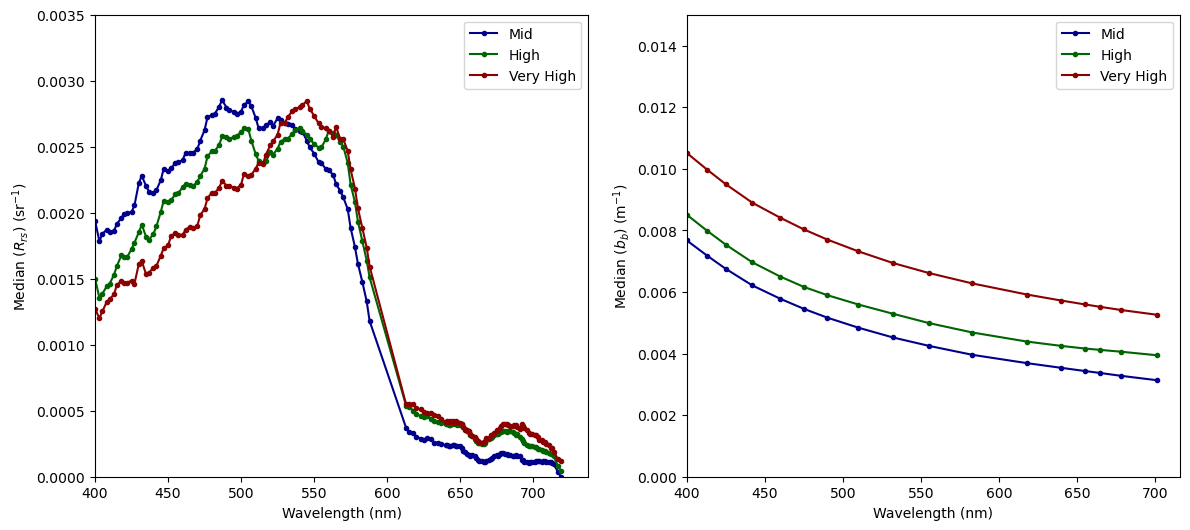

In [7]:
level_colors = {
    "mid": "darkblue",
    "high": "darkgreen",
    "very_high": "darkred",}

level_labels = {
    "mid": "Mid",
    "high": "High",
    "very_high": "Very High",}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for level in ["mid", "high", "very_high"]:
    color = level_colors[level]
    label = level_labels[level]

    rrs_med = rrs_pn[rrs_pn["level"] == level].groupby("wavelength")["rrs"].median()
    ax1.plot(rrs_med.index, rrs_med.values, marker="o", markersize=3,
              label=label, color=color)

    bb_med = bb_pn[bb_pn["level"] == level].groupby("wavelength")["bb"].median()
    ax2.plot(bb_med.index, bb_med.values, marker="o", markersize=3,
              label=label, color=color)

ax1.set_xlabel("Wavelength (nm)")
ax1.set_ylabel(r"Median ($R_{rs}$) (sr$^{-1}$)")
ax1.set_xlim(400, )
ax1.set_ylim(0, 0.0035)
ax1.legend()

ax2.set_xlabel("Wavelength (nm)")
ax2.set_ylabel(r"Median ($b_{b}$) (m$^{-1}$)")
ax2.set_xlim(400, )
ax2.set_ylim(0, 0.015)
ax2.legend()

plt.savefig("PN rrs bb.png", dpi=300, bbox_inches="tight")
plt.show()

In [8]:

row_order = ["SAM (whole)", "SAM (part)", "Bright (whole)", "Bright (part)"]

r2_xqaa = pd.Series({
    "Bright (whole)": 0.0257,
    "SAM (whole)":    0.0377,
    "Bright (part)":  0.013292,
    "SAM (part)":     0.000161,
}, name="$b_{bp}$")

r2_arrs = pd.Series({
    "Bright (whole)": 0.0236,
    "SAM (whole)":    0.00335,
    "Bright (part)":  0.0252,
    "SAM (part)":     0.000949,
}, name="$aR_{rs}$")

r2_matrix = pd.concat([r2_xqaa, r2_arrs], axis=1).reindex(row_order)
r2_matrix

,$b_{bp}$,$aR_{rs}$
SAM (whole),0.037700,0.003350
SAM (part),0.000161,0.000949
Bright (whole),0.025700,0.023600
Bright (part),0.013292,0.025200


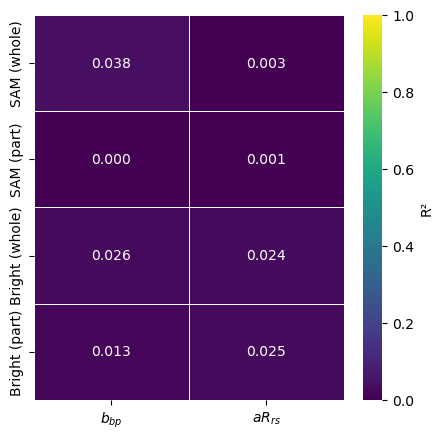

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(r2_matrix, annot=True, fmt=".3f", cmap="viridis", vmin=0, vmax=1,
            cbar_kws={"label": "R\u00b2"}, linewidths=0.5, linecolor="white", ax=ax)
plt.savefig("Heat Map.png", dpi=300, bbox_inches="tight")
plt.show()